# KLASIFIKASI GENRE GAME BERDASARKAN SINOPSIS (MULTI-LABEL) — TRANSFORMER
---
**Author:** *Muhammad Wira Widhana [24.55.2717]*

> **Pendekatan:** Versi ini menggantikan metode Machine Learning klasik (TF-IDF + Naive Bayes / KNN / SVM) dengan model **Transformer (DistilBERT)** untuk klasifikasi **multi-label** genre game berdasarkan sinopsis. Struktur dan tahapan dibuat semirip mungkin dengan notebook multi-label sebelumnya agar mudah dibandingkan.

## Instalasi & Library

> **Penjelasan singkat:** Transformer memerlukan pustaka `transformers`, `torch`, dan `datasets`. Jalankan sel instalasi di bawah **hanya jika** pustaka belum tersedia di environment Anda.

In [1]:
# INSTALASI (jalankan hanya jika belum terpasang)
# Hapus tanda komentar baris di bawah bila perlu menginstal.

# !pip install -q "transformers>=4.41" torch "datasets>=2.19" scikit-learn
# !pip install -U "transformers[torch]" "accelerate>=1.1.0" datasets

import accelerate, transformers, torch
print("accelerate :", accelerate.__version__)
print("transformers:", transformers.__version__)
print("CUDA tersedia:", torch.cuda.is_available())

accelerate : 1.13.0
transformers: 5.10.2
CUDA tersedia: True


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import ast
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import (
    classification_report, hamming_loss,
    precision_score, recall_score, f1_score,
    mean_squared_error, multilabel_confusion_matrix
)

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
)
from datasets import Dataset

# Cek ketersediaan GPU (disarankan untuk fine-tuning DistilBERT)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
if device == "cuda":
    print("GPU   :", torch.cuda.get_device_name(0))

Device: cuda
GPU   : NVIDIA GeForce RTX 3060


In [3]:
# REPRODUCIBILITAS
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## Load dan Memeriksa Data (Data Loading & EDA)

Load Dataset

In [4]:
# Load Dataset
df_raw = pd.read_csv('games_fixed.csv')

print("Ukuran awal dataset:", df_raw.shape)
df_raw.head()

Ukuran awal dataset: (122611, 36)


,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Median playtime two weeks,Average playtime forever,Median playtime forever,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
0,10,Counter-Strike,"Nov 1, 2000",10000000 - 20000000,7323,0,1.99,80,0,Play the world's number 1 online action game. ...,...,99,10735,185,['Valve'],['Valve'],"['Multi-player', 'PvP', 'Online PvP', 'Shared/...",['Action'],"{'Action': 5504, 'FPS': 4929, 'Multiplayer': 3...",['https://shared.akamai.steamstatic.com/store_...,[]
1,100,Counter-Strike: Condition Zero,"Mar 1, 2004",10000000 - 20000000,83,0,1.99,80,0,"With its extensive Tour of Duty campaign, a ne...",...,1,431,32,['Valve'],['Valve'],"['Single-player', 'Multi-player', 'Color Alter...",['Action'],"{'Action': 1339, 'FPS': 979, 'Shooter': 723, '...",['https://shared.akamai.steamstatic.com/store_...,[]
2,1000000,ASCENXION,"May 14, 2021",0 - 20000,0,0,1.49,0,1,ASCENXION is a 2D shoot 'em up game where you ...,...,0,0,0,['IndigoBlue Game Studio'],['PsychoFlux Entertainment'],"['Single-player', 'Steam Achievements', 'Parti...","['Action', 'Adventure', 'Indie']","{""Shoot 'Em Up"": 186, 'Metroidvania': 181, 'Bu...",['https://shared.akamai.steamstatic.com/store_...,[]
3,1000010,Crown Trick,"Oct 16, 2020",500000 - 1000000,14,0,4.99,0,2,Crown Trick is a beautifully animated rogue-li...,...,0,702,397,['NEXT Studios'],"['Team17', 'NEXT Studios']","['Single-player', 'Steam Achievements', 'Steam...","['Adventure', 'Indie', 'RPG', 'Strategy']","{'Rogue-like': 275, 'Turn-Based Combat': 258, ...",['https://shared.akamai.steamstatic.com/store_...,[]
4,1000030,"Cook, Serve, Delicious! 3?!","Oct 14, 2020",100000 - 200000,27,0,4.99,75,1,Hit the road in this massive sequel to the mil...,...,0,281,118,['Vertigo Gaming Inc.'],['Vertigo Gaming Inc.'],"['Single-player', 'Multi-player', 'Co-op', 'Sh...","['Action', 'Indie', 'Simulation', 'Strategy']","{'Typing': 227, 'Management': 219, 'Difficult'...",['https://shared.akamai.steamstatic.com/store_...,[]


> **Penjelasan singkat:** Membaca dataset `games_fixed.csv` (dataset dari Kaggle, hasil scraping Steam Web API & SteamSpy). Dataset asli berisi lebih dari 100.000 game; file sampel hanya dipakai untuk memahami struktur kolom.

Exploratory Data Analysis (EDA)

In [5]:
# Exploratory Data Analysis (EDA)

df = df_raw[['Name', 'About the game', 'Genres']].copy()

df.rename(columns={
    'Name': 'title',
    'About the game': 'synopsis',
    'Genres': 'genre_raw'
}, inplace=True)

print("Jumlah data setelah seleksi kolom:", df.shape)
df.sample(5)

Jumlah data setelah seleksi kolom: (122611, 3)


,title,synopsis,genre_raw
33398,Corn Defenders,Corn Defenders A modern game inspired by many ...,"['Action', 'Adventure', 'Casual', 'Free To Pla..."
24368,ATOLL,The earth has been struck by an extinction lev...,"['Action', 'Adventure', 'Indie', 'Simulation']"
99907,Gobotix: Duo,"Welcome to the Gobotix, a robot manufacturing ...","['Casual', 'Indie', 'Free To Play']"
48012,Ed's world story,Protagonist 'Ed' lives in Kakariko village. He...,"['Action', 'Adventure', 'Casual', 'Indie']"
109018,ObserVRtarium,"The ObserVRtarium is an interactive, room-scal...","['Simulation', 'Early Access']"


Cek missing values

In [6]:
# Cek missing values
df.isna().sum()

title           1
synopsis     8448
genre_raw       0
dtype: int64

Hapus baris yang tidak punya sinopsis atau genre

In [7]:
# Hapus baris yang tidak punya sinopsis atau genre
df = df.dropna(subset=['synopsis', 'genre_raw']).reset_index(drop=True)

# Tambahan: hapus genre yang kosong secara konten, seperti [], [''], dll.
df['genre_raw'] = df['genre_raw'].astype(str).str.strip()

df = df[~df['genre_raw'].isin(['[]', "['']", '[""]', '', 'nan'])].reset_index(drop=True)

print("Jumlah data setelah drop NA dan genre kosong:", df.shape)

Jumlah data setelah drop NA dan genre kosong: (114022, 3)


## Normalisasi Genre (Multi-Label)

> **Pendekatan Multi-Label:** Sama seperti notebook multi-label sebelumnya, setiap game dapat memiliki lebih dari satu genre. Genre `indie` dan `casual` dibuang karena keduanya bukan genre gameplay murni — `indie` adalah label produksi/developer, sedangkan `casual` adalah segmentasi audiens/tingkat kesulitan, bukan jenis konten permainan.
>
> Genre target: **action, adventure, rpg, simulation** (4 genre gameplay murni).

In [8]:
# Genre target: 4 genre gameplay murni (tanpa 'indie' & 'casual')
target_genres = {'action', 'adventure', 'rpg', 'simulation'}

def parse_genre_list(genre_str):
    # Parse string genre "['Action', 'Indie']" -> ['action', 'indie'] secara aman.
    if pd.isna(genre_str):
        return []
    if isinstance(genre_str, list):
        raw_list = genre_str
    else:
        text = str(genre_str).strip()
        try:
            raw_list = ast.literal_eval(text)
        except (ValueError, SyntaxError):
            raw_list = [g.strip() for g in text.split(',')]
    cleaned = [g.strip().lower() for g in raw_list if isinstance(g, str)]
    return cleaned

df['genre_list'] = df['genre_raw'].apply(parse_genre_list)

# Pertahankan semua genre target (multi-label)
df['genre_labels'] = df['genre_list'].apply(
    lambda lst: sorted(set(g for g in lst if g in target_genres))
)
df['genre_count'] = df['genre_labels'].apply(len)

print("Distribusi jumlah genre target per game:")
print(df['genre_count'].value_counts().sort_index())

Distribusi jumlah genre target per game:
genre_count
0    25759
1    51293
2    27328
3     8309
4     1333
Name: count, dtype: int64


In [9]:
# Buang game yang tidak punya genre target sama sekali
df_main = df[df['genre_count'] >= 1].copy().reset_index(drop=True)

print("Jumlah data multi-label (>=1 genre target):", df_main.shape)
df_main[['title', 'genre_raw', 'genre_labels', 'genre_count']].head(10)

Jumlah data multi-label (>=1 genre target): (88263, 6)


,title,genre_raw,genre_labels,genre_count
0,Counter-Strike,['Action'],[action],1
1,Counter-Strike: Condition Zero,['Action'],[action],1
2,ASCENXION,"['Action', 'Adventure', 'Indie']","[action, adventure]",2
3,Crown Trick,"['Adventure', 'Indie', 'RPG', 'Strategy']","[adventure, rpg]",2
4,"Cook, Serve, Delicious! 3?!","['Action', 'Indie', 'Simulation', 'Strategy']","[action, simulation]",2
5,我的一个多重人格朋友,"['Adventure', 'Casual', 'Indie', 'RPG', 'Simul...","[adventure, rpg, simulation]",3
6,Zengeon,"['Action', 'Adventure', 'Indie', 'RPG']","[action, adventure, rpg]",3
7,干支セトラ 陽ノ卷｜干支etc. 陽之卷,"['Adventure', 'Indie', 'RPG', 'Strategy']","[adventure, rpg]",2
8,Jumping Master(跳跳大咖),"['Action', 'Adventure', 'Casual', 'Free To Pla...","[action, adventure]",2
9,Tower of Origin2-Worm's Nest,"['Indie', 'RPG']",[rpg],1


Sebaran genre

In [10]:
# Frekuensi kemunculan tiap genre (satu game bisa dihitung di beberapa genre)
genre_counter = Counter()
for labels in df_main['genre_labels']:
    genre_counter.update(labels)

genre_freq = pd.Series(genre_counter).sort_values(ascending=False)
print(genre_freq)

action        46131
adventure     45063
simulation    24083
rpg           20931
dtype: int64


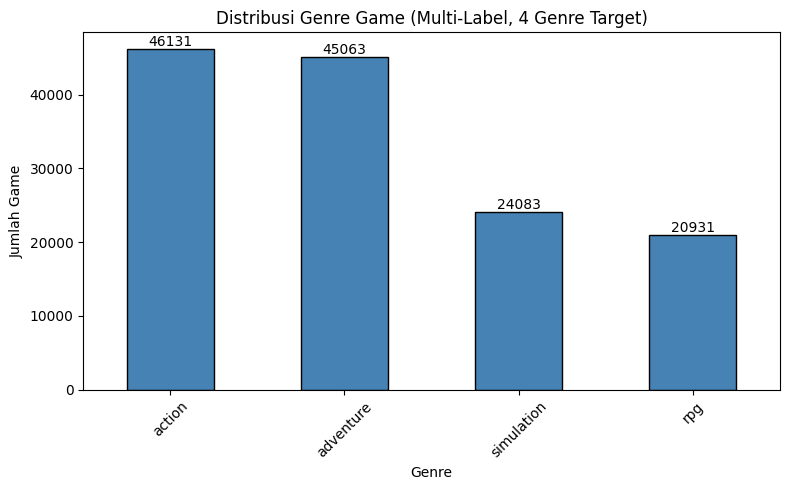

In [11]:
# Visualisasi distribusi genre (multi-label)
plt.figure(figsize=(8, 5))
ax = genre_freq.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribusi Genre Game (Multi-Label, 4 Genre Target)')
plt.xlabel('Genre')
plt.ylabel('Jumlah Game')
plt.xticks(rotation=45)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

## Filter Bahasa Inggris & Text Cleaning

In [12]:
# TEXT CLEANING & LANGUAGE FILTERING (ENGLISH-ONLY)
def basic_english_filter(text):
    # Filter sederhana: pastikan teks dominan karakter Latin dan tidak terlalu pendek.
    if not isinstance(text, str):
        return False
    clean = re.sub(r'[^A-Za-z\s]', ' ', text)
    clean = re.sub(r'\s+', ' ', clean).strip()
    if len(clean.split()) < 3:
        return False
    ratio = len(clean) / max(len(text), 1)
    return ratio >= 0.7

df_main['is_english'] = df_main['synopsis'].apply(basic_english_filter)
print(df_main['is_english'].value_counts())

df_main = df_main[df_main['is_english']].drop(columns=['is_english']).reset_index(drop=True)
print("Jumlah data setelah filter bahasa Inggris:", df_main.shape)

is_english
True     86539
False     1724
Name: count, dtype: int64
Jumlah data setelah filter bahasa Inggris: (86539, 6)


## Penghapusan Sinopsis Terlalu Pendek & Tidak Informatif

> **Penjelasan singkat (versi diperbaiki):** Metode lama memakai *persentil ke-5* yang **selalu** membuang 5% data terpendek berapa pun isinya, dan ambangnya berubah-ubah mengikuti dataset sehingga sulit dijustifikasi di paper. Versi ini memakai kriteria **absolut + berbasis konten** yang lebih reprodusibel:
> 1. **Ambang minimum absolut** (`MIN_WORDS`, `MIN_CHARS`) — sinopsis harus cukup panjang untuk bisa menebak genre, bukan sekadar relatif terhadap data.
> 2. **Buang teks placeholder** — mis. "no description", "coming soon", "tba" yang tidak informatif.
> 3. **Buang sinopsis duplikat** — banyak game Steam memakai sinopsis copy-paste (boilerplate); duplikat membuat model menghafal dan membocorkan data antar train/test.

In [13]:
# Parameter ambang (absolut & mudah dijustifikasi di paper)
MIN_WORDS = 10    # minimal 10 kata bermakna untuk dapat menebak genre
MIN_CHARS = 40    # minimal 40 karakter

df_main['word_count'] = df_main['synopsis'].apply(lambda x: len(str(x).split()))
df_main['char_count'] = df_main['synopsis'].apply(lambda x: len(str(x).strip()))

print("Statistik panjang sinopsis (kata):")
print(df_main['word_count'].describe())

Statistik panjang sinopsis (kata):
count    86539.000000
mean       225.879777
std        167.791643
min          3.000000
25%        123.000000
50%        188.000000
75%        282.000000
max      11530.000000
Name: word_count, dtype: float64


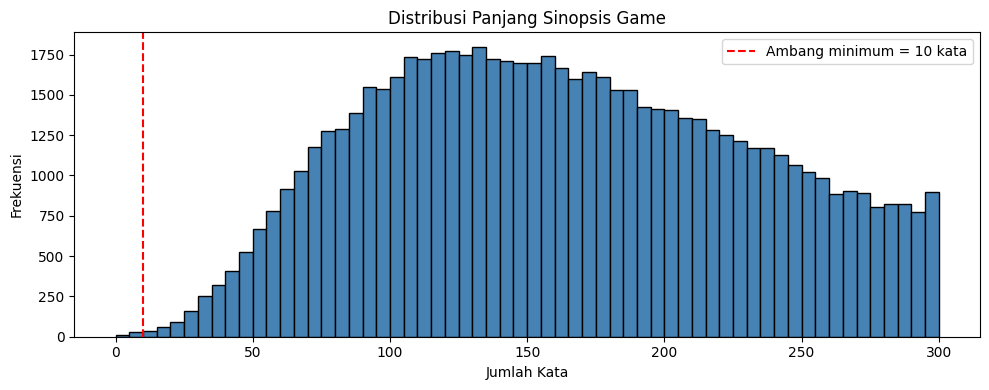

In [14]:
# Visualisasi distribusi panjang sinopsis + ambang minimum absolut
plt.figure(figsize=(10, 4))
plt.hist(df_main['word_count'], bins=60, range=(0, 300), color='steelblue', edgecolor='black')
plt.axvline(MIN_WORDS, color='red', linestyle='--', label=f'Ambang minimum = {MIN_WORDS} kata')
plt.xlabel('Jumlah Kata'); plt.ylabel('Frekuensi')
plt.title('Distribusi Panjang Sinopsis Game')
plt.legend(); plt.tight_layout(); plt.show()

In [15]:
# Terapkan tiga kriteria penyaringan
_syn = df_main['synopsis'].astype(str).str.strip()

# 1) Teks placeholder / tidak informatif
placeholder_re = re.compile(r'^(no description( available)?|coming soon|tba|tbd|n/?a|none|\.+|-+)$', re.I)
is_placeholder = _syn.apply(lambda s: bool(placeholder_re.match(s)))

# 2) Terlalu pendek (jumlah kata ATAU karakter di bawah ambang)
too_short = (df_main['word_count'] < MIN_WORDS) | (df_main['char_count'] < MIN_CHARS)

# 3) Sinopsis duplikat (boilerplate copy-paste antar game)
is_dup = _syn.str.lower().duplicated(keep='first')

remove_mask = is_placeholder | too_short | is_dup
before = len(df_main)
print(f"Placeholder / tidak informatif         : {int(is_placeholder.sum())}")
print(f"Terlalu pendek (<{MIN_WORDS} kata / <{MIN_CHARS} char) : {int(too_short.sum())}")
print(f"Sinopsis duplikat                      : {int(is_dup.sum())}")
print(f"Total baris dibuang (gabungan)         : {int(remove_mask.sum())}")

df_main = df_main[~remove_mask].drop(columns=['word_count', 'char_count']).reset_index(drop=True)
after = len(df_main)
print(f"\nData sebelum : {before}")
print(f"Data sesudah : {after}  (dibuang {before - after}, {(before - after) / before * 100:.2f}%)")

Placeholder / tidak informatif         : 0
Terlalu pendek (<10 kata / <40 char) : 38
Sinopsis duplikat                      : 312
Total baris dibuang (gabungan)         : 350

Data sebelum : 86539
Data sesudah : 86189  (dibuang 350, 0.40%)


## Text Preprocessing untuk Transformer

> **Perbedaan penting dari versi ML klasik:** DistilBERT memakai *subword tokenizer* (WordPiece) dan **memahami konteks kalimat**, sehingga **TIDAK** dilakukan stemming maupun stopword removal — keduanya justru merusak struktur kalimat yang dibutuhkan Transformer. Teks hanya dibersihkan ringan (rapikan spasi & buang URL); huruf besar/kecil dibiarkan karena tokenizer `distilbert-base-uncased` menanganinya otomatis.

In [16]:
# LIGHT CLEANING untuk Transformer (tanpa stemming / stopword removal)
def light_clean(text):
    text = str(text)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)   # buang URL
    text = re.sub(r'\s+', ' ', text).strip()         # rapikan spasi
    return text

df_main['text'] = df_main['synopsis'].apply(light_clean)

df_main[['title', 'genre_labels', 'text']].head(5)

,title,genre_labels,text
0,Counter-Strike,[action],Play the world's number 1 online action game. ...
1,Counter-Strike: Condition Zero,[action],"With its extensive Tour of Duty campaign, a ne..."
2,ASCENXION,"[action, adventure]",ASCENXION is a 2D shoot 'em up game where you ...
3,Crown Trick,"[adventure, rpg]",Crown Trick is a beautifully animated rogue-li...
4,"Cook, Serve, Delicious! 3?!","[action, simulation]",Hit the road in this massive sequel to the mil...


## Penyeimbangan Distribusi Genre (Undersampling Multi-Label)

> **Penjelasan singkat:** Distribusi genre timpang (action/adventure jauh lebih banyak daripada rpg). Sesuai permintaan, penyeimbangan dilakukan dengan **undersampling** (mengurangi game pada genre mayoritas), **bukan augmentasi**. Target tiap genre disamakan ke genre paling sedikit.
>
> **Catatan penting (multi-label):** karena satu game bisa memiliki >1 genre, distribusi tidak dapat dibuat sama **persis** — mengurangi satu game otomatis mengurangi semua genre yang melekat padanya. Algoritme memakai *greedy undersampling*: sebuah game dipertahankan selama masih ada genre miliknya yang belum mencapai target, sehingga genre minoritas tetap terjaga penuh dan genre mayoritas ditekan mendekati target.

In [17]:
# PENYEIMBANGAN DISTRIBUSI via UNDERSAMPLING (tanpa augmentasi)
freq_before = Counter()
for labels in df_main['genre_labels']:
    freq_before.update(labels)

TARGET_PER_GENRE = min(freq_before.values())   # samakan ke genre paling sedikit
print("Distribusi sebelum balancing :", dict(freq_before.most_common()))
print("Target per genre             :", TARGET_PER_GENRE)

# Greedy undersampling: acak data, lalu pertahankan game selama masih ada
# genre miliknya yang belum mencapai target.
df_shuffled = df_main.sample(frac=1, random_state=SEED).reset_index(drop=True)
counts = Counter()
keep_idx = []
for i, labels in enumerate(df_shuffled['genre_labels']):
    if any(counts[g] < TARGET_PER_GENRE for g in labels):
        keep_idx.append(i)
        counts.update(labels)

df_main = df_shuffled.iloc[keep_idx].reset_index(drop=True)

freq_after = Counter()
for labels in df_main['genre_labels']:
    freq_after.update(labels)
print("\nDistribusi setelah balancing :", dict(freq_after.most_common()))
print("Jumlah data setelah balancing:", len(df_main))

Distribusi sebelum balancing : {'action': 45491, 'adventure': 43857, 'simulation': 23458, 'rpg': 19779}
Target per genre             : 19779

Distribusi setelah balancing : {'adventure': 28106, 'action': 26523, 'simulation': 20455, 'rpg': 19779}
Jumlah data setelah balancing: 57019


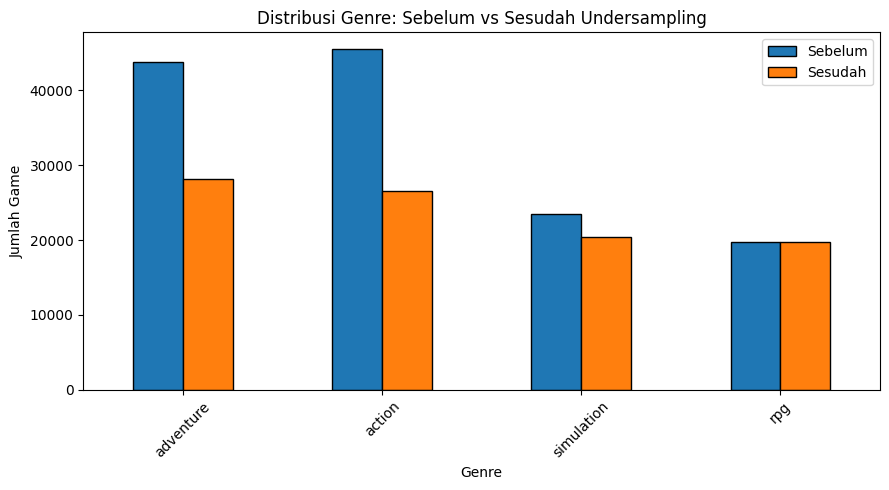

,Sebelum,Sesudah
adventure,43857,28106
action,45491,26523
simulation,23458,20455
rpg,19779,19779


In [18]:
# Visualisasi distribusi genre: sebelum vs sesudah balancing
cmp_df = pd.DataFrame({
    'Sebelum': pd.Series(dict(freq_before)),
    'Sesudah': pd.Series(dict(freq_after)),
}).fillna(0).astype(int).sort_values('Sesudah', ascending=False)

cmp_df.plot(kind='bar', figsize=(9, 5), edgecolor='black')
plt.title('Distribusi Genre: Sebelum vs Sesudah Undersampling')
plt.xlabel('Genre'); plt.ylabel('Jumlah Game')
plt.xticks(rotation=45)
plt.tight_layout(); plt.show()
cmp_df

## Encoding Label Multi-Label

> **Penjelasan singkat:** `MultiLabelBinarizer` mengubah list genre seperti `['action', 'rpg']` menjadi vektor biner `[1, 0, 0, 1, 0]`. Untuk Transformer multi-label, label disimpan sebagai **float** karena loss `BCEWithLogitsLoss` membutuhkan target bertipe desimal.

In [19]:
# MULTI-LABEL BINARIZATION
mlb = MultiLabelBinarizer(classes=sorted(target_genres))
Y = mlb.fit_transform(df_main['genre_labels']).astype('float32')

classes = list(mlb.classes_)
num_labels = len(classes)
print("Urutan kelas:", classes)
print("Bentuk matriks label (Y):", Y.shape)

contoh = pd.DataFrame(Y[:5].astype(int), columns=classes)
contoh.insert(0, 'genre_labels', df_main['genre_labels'][:5].values)
contoh

Urutan kelas: ['action', 'adventure', 'rpg', 'simulation']
Bentuk matriks label (Y): (57019, 4)


,genre_labels,action,adventure,rpg,simulation
0,[adventure],0,1,0,0
1,"[action, adventure]",1,1,0,0
2,[adventure],0,1,0,0
3,[action],1,0,0,0
4,"[action, adventure]",1,1,0,0


## Split Data (Train / Validation / Test)

> **Penjelasan singkat:** Sesuai proposal digunakan rasio **80% train : 20% test**. Dari porsi train disisihkan **10% sebagai data validasi** untuk *early stopping* dan pemilihan model terbaik. Multi-label tidak memakai `stratify` standar; pembagian acak dengan `random_state` tetap agar reprodusibel.

In [20]:
# SPLIT 80/20 (train/test), lalu sisihkan 10% dari train sebagai validasi
texts = df_main['text'].tolist()

X_train_full, X_test, y_train_full, y_test = train_test_split(
    texts, Y, test_size=0.2, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1, random_state=SEED
)

print("Jumlah data train     :", len(X_train))
print("Jumlah data validasi  :", len(X_val))
print("Jumlah data test      :", len(X_test))

Jumlah data train     : 41053
Jumlah data validasi  : 4562
Jumlah data test      : 11404


## Tokenisasi (DistilBERT)

> **Penjelasan singkat:** Teks diubah menjadi token-id memakai tokenizer `distilbert-base-uncased`. `max_length=256` cukup untuk sinopsis game dan hemat memori GPU (cocok untuk RTX 3060 6GB). Padding ditangani dinamis oleh `DataCollatorWithPadding` agar efisien.

In [21]:
MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def make_dataset(texts, labels):
    return Dataset.from_dict({
        "text": texts,
        "labels": [list(map(float, row)) for row in labels]
    })

train_ds = make_dataset(X_train, y_train)
val_ds   = make_dataset(X_val,   y_val)
test_ds  = make_dataset(X_test,  y_test)

def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)

train_ds = train_ds.map(tokenize_fn, batched=True, remove_columns=["text"])
val_ds   = val_ds.map(tokenize_fn,   batched=True, remove_columns=["text"])
test_ds  = test_ds.map(tokenize_fn,  batched=True, remove_columns=["text"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Map:   0%|          | 0/41053 [00:00<?, ? examples/s]

Map:   0%|          | 0/4562 [00:00<?, ? examples/s]

Map:   0%|          | 0/11404 [00:00<?, ? examples/s]

## Model DistilBERT (Multi-Label)

> **Penjelasan singkat:** Model `DistilBertForSequenceClassification` dikonfigurasi dengan `problem_type="multi_label_classification"`. Dengan ini model otomatis memakai **aktivasi sigmoid** (bukan softmax) dan **loss `BCEWithLogitsLoss`**, sehingga tiap genre diprediksi independen — sebuah game bisa memiliki beberapa genre sekaligus (analog One-vs-Rest pada versi ML klasik).

In [22]:
id2label = {i: c for i, c in enumerate(classes)}
label2id = {c: i for i, c in enumerate(classes)}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    problem_type="multi_label_classification",
    id2label=id2label,
    label2id=label2id,
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Metrik Evaluasi

> **Penjelasan singkat — pemilihan metrik F1.** Metrik sesuai proposal: **Accuracy, Precision, Recall, F1-Score**, dalam konteks multi-label. Untuk Precision/Recall/F1, nilai dihitung **per genre terlebih dahulu lalu dirata-ratakan secara setara antar genre**. Pendekatan ini dipilih (bukan agregasi global seluruh keputusan label) karena distribusi genre tidak seimbang: dengan merata-ratakan tiap genre secara setara, genre yang datanya sedikit tetap memberi kontribusi yang sama, sehingga angka F1 mencerminkan performa nyata di **semua** genre — bukan hanya didominasi genre mayoritas. Disertakan pula MSE/RMSE pada matriks label biner (pada data biner, MSE setara dengan Hamming Loss).

In [23]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = sigmoid(logits)
    preds = (probs >= 0.5).astype(int)
    labels = labels.astype(int)

    mse = mean_squared_error(labels, preds)
    return {
        "f1":        f1_score(labels, preds, average='macro', zero_division=0),
        "precision": precision_score(labels, preds, average='macro', zero_division=0),
        "recall":    recall_score(labels, preds, average='macro', zero_division=0),
        "accuracy":  1 - hamming_loss(labels, preds),  # akurasi per-keputusan label
        "mse":       mse,
        "rmse":      np.sqrt(mse),
    }


## Training (Fine-Tuning)

> **Penjelasan singkat:** Fine-tuning memakai `Trainer` HuggingFace. Parameter dipilih agar muat di GPU 6GB (RTX 3060): `batch_size=16`, `fp16=True`, `max_length=256`. `load_best_model_at_end` + `EarlyStoppingCallback` memilih model terbaik berdasarkan **F1-Score** pada data validasi.
>
> **Catatan dataset besar (>100.000 data):** untuk uji coba cepat set `SAMPLE_FRAC < 1.0` agar melatih sebagian data dulu; setel `SAMPLE_FRAC = 1.0` untuk pelatihan penuh. Pada data penuh, 1 epoch bisa lama — gunakan GPU.
>
> *Catatan kompatibilitas:* jika versi `transformers` Anda lama dan `eval_strategy` error, ganti menjadi `evaluation_strategy`.

In [24]:
# (Opsional) Subsampling untuk uji coba cepat. Set 1.0 untuk data penuh.
SAMPLE_FRAC = 1.0

if SAMPLE_FRAC < 1.0:
    n = int(len(train_ds) * SAMPLE_FRAC)
    train_ds_used = train_ds.shuffle(seed=SEED).select(range(n))
    print(f"Memakai subset train: {n} dari {len(train_ds)}")
else:
    train_ds_used = train_ds

batch_size = 16
training_args = TrainingArguments(
    output_dir="./distilbert-genre-multilabel",
    learning_rate=2e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=4,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds_used,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,Precision Micro,Recall Micro,Acc Label,Acc Subset,Mse,Rmse
1,0.401402,0.427316,0.745770,0.741497,0.812402,0.689239,0.805677,0.453968,0.194323,0.440820
2,0.390412,0.405559,0.773263,0.770609,0.786566,0.760403,0.815596,0.471065,0.184404,0.429423
3,0.335141,0.417692,0.771625,0.771494,0.784736,0.758945,0.814226,0.464051,0.185774,0.431015
4,0.282016,0.431696,0.768507,0.767677,0.779992,0.757355,0.811322,0.457256,0.188678,0.434371


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=10264, training_loss=0.36934112763832255, metrics={'train_runtime': 1341.3551, 'train_samples_per_second': 122.422, 'train_steps_per_second': 7.652, 'total_flos': 1.0876756163223552e+16, 'train_loss': 0.36934112763832255, 'epoch': 4.0})

## Evaluasi pada Data Test

In [25]:
# Prediksi pada data test
pred_output = trainer.predict(test_ds)
logits = pred_output.predictions
probs = sigmoid(logits)
y_pred = (probs >= 0.5).astype(int)
y_true = np.array(y_test).astype(int)

print("=== METRIK DISTILBERT (threshold = 0.5) ===")
print(f"Accuracy  : {(1-hamming_loss(y_true, y_pred))*100:.2f}%")
print(f"Precision : {precision_score(y_true, y_pred, average='macro', zero_division=0)*100:.2f}%")
print(f"Recall    : {recall_score(y_true, y_pred, average='macro', zero_division=0)*100:.2f}%")
print(f"F1-Score  : {f1_score(y_true, y_pred, average='macro', zero_division=0)*100:.2f}%")
print()
print(classification_report(y_true, y_pred, target_names=classes, zero_division=0))


=== METRIK DISTILBERT (threshold = 0.5) ===
F1-micro  : 77.27%
F1-macro  : 76.96%
Precision : 78.57%
Recall    : 76.02%
Acc(label): 81.39%

              precision    recall  f1-score   support

      action       0.79      0.83      0.81      5267
   adventure       0.72      0.81      0.76      5653
         rpg       0.83      0.69      0.75      3890
  simulation       0.85      0.67      0.75      4172

   micro avg       0.79      0.76      0.77     18982
   macro avg       0.80      0.75      0.77     18982
weighted avg       0.79      0.76      0.77     18982
 samples avg       0.81      0.80      0.77     18982



Confusion Matrix per Genre

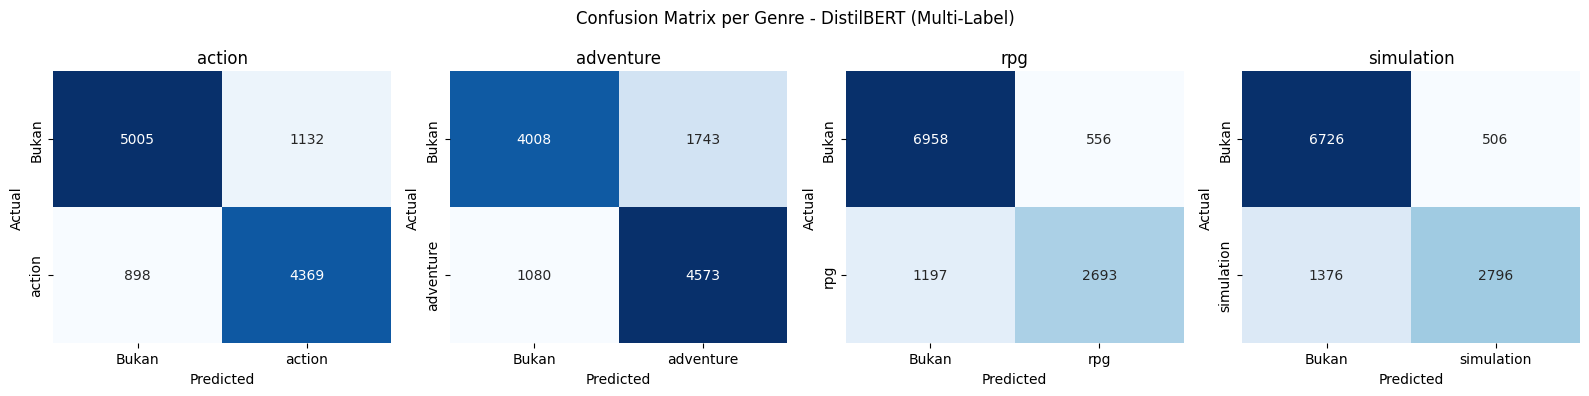

In [26]:
mcm = multilabel_confusion_matrix(y_true, y_pred)
fig, axes = plt.subplots(1, num_labels, figsize=(4*num_labels, 4))
for i, (genre, cm) in enumerate(zip(classes, mcm)):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i],
                xticklabels=['Bukan', genre], yticklabels=['Bukan', genre])
    axes[i].set_title(genre)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
plt.suptitle('Confusion Matrix per Genre - DistilBERT (Multi-Label)')
plt.tight_layout()
plt.show()

## (Opsional) Penyetelan Threshold per Genre

> **Penjelasan singkat:** Pada multi-label, ambang 0.5 belum tentu optimal untuk setiap genre. Mencari threshold terbaik per genre pada **data validasi** lalu menerapkannya ke test sering menaikkan **F1-Score** tanpa melatih ulang model. Opsional, untuk membantu mengejar target F1.

In [27]:
# Cari threshold terbaik per genre menggunakan data validasi
val_logits = trainer.predict(val_ds).predictions
val_probs = sigmoid(val_logits)
y_val_true = np.array(y_val).astype(int)

best_thresholds = np.full(num_labels, 0.5)
for j in range(num_labels):
    best_f1, best_t = -1, 0.5
    for t in np.arange(0.1, 0.9, 0.05):
        pred_j = (val_probs[:, j] >= t).astype(int)
        f1j = f1_score(y_val_true[:, j], pred_j, zero_division=0)
        if f1j > best_f1:
            best_f1, best_t = f1j, t
    best_thresholds[j] = best_t

print("Threshold terbaik per genre:")
for c, t in zip(classes, best_thresholds):
    print(f"  {c:12s}: {t:.2f}")

# Terapkan ke test
y_pred_tuned = (probs >= best_thresholds).astype(int)

print()
print("=== METRIK DISTILBERT (threshold tuned) ===")
print(f"Accuracy  : {(1-hamming_loss(y_true, y_pred_tuned))*100:.2f}%")
print(f"Precision : {precision_score(y_true, y_pred_tuned, average='macro', zero_division=0)*100:.2f}%")
print(f"Recall    : {recall_score(y_true, y_pred_tuned, average='macro', zero_division=0)*100:.2f}%")
print(f"F1-Score  : {f1_score(y_true, y_pred_tuned, average='macro', zero_division=0)*100:.2f}%")
print(classification_report(y_true, y_pred_tuned, target_names=classes, zero_division=0))

Threshold terbaik per genre:
  action      : 0.50
  adventure   : 0.40
  rpg         : 0.45
  simulation  : 0.30

=== METRIK DISTILBERT (threshold tuned) ===
F1-micro  : 77.83%
F1-macro  : 77.72%
              precision    recall  f1-score   support

      action       0.79      0.83      0.81      5267
   adventure       0.68      0.88      0.77      5653
         rpg       0.81      0.72      0.76      3890
  simulation       0.73      0.81      0.77      4172

   micro avg       0.74      0.82      0.78     18982
   macro avg       0.75      0.81      0.78     18982
weighted avg       0.75      0.82      0.78     18982
 samples avg       0.79      0.85      0.78     18982



## Perhitungan MSE & RMSE

> **Penjelasan singkat:** Dihitung pada matriks label biner. Pada prediksi biner (0/1), **MSE setara dengan Hamming Loss** dan RMSE adalah akarnya — keduanya semakin kecil semakin baik. Dicantumkan untuk kelengkapan sesuai arahan, namun F1 tetap metrik utama penilaian.

In [28]:
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
print(f"MSE  : {mse:.4f}  (setara Hamming Loss)")
print(f"RMSE : {rmse:.4f}")

MSE  : 0.1861  (setara Hamming Loss)
RMSE : 0.4314


## Tabel Perbandingan Akhir (Lengkap: Metrik Evaluasi + MSE & RMSE)

> **Penjelasan singkat:** Satu tabel ringkasan berisi seluruh metrik evaluasi (Accuracy, Precision, Recall, F1-Score) **digabung** dengan MSE & RMSE, untuk semua model. Ini tabel performa akhir yang bisa langsung dipakai di paper/thesis.

In [29]:
def metric_row(name, yt, yp):
    mse = mean_squared_error(yt, yp)
    return {
        'Model':         name,
        'Accuracy (%)':  round((1 - hamming_loss(yt, yp)) * 100, 2),
        'Precision (%)': round(precision_score(yt, yp, average='macro', zero_division=0) * 100, 2),
        'Recall (%)':    round(recall_score(yt, yp, average='macro', zero_division=0) * 100, 2),
        'F1-Score (%)':  round(f1_score(yt, yp, average='macro', zero_division=0) * 100, 2),
        'MSE':           round(mse, 4),
        'RMSE':          round(np.sqrt(mse), 4),
    }

rows = [
    metric_row('DistilBERT (thr=0.5)',   y_true, y_pred),
    metric_row('DistilBERT (thr tuned)', y_true, y_pred_tuned),
]
compare_df = pd.DataFrame(rows).sort_values('F1-Score (%)', ascending=False).reset_index(drop=True)
print("TABEL PERFORMA AKHIR — Perbandingan Model (Metrik + MSE/RMSE)")
compare_df


TABEL PERFORMA AKHIR — Perbandingan Model (Metrik + MSE/RMSE)


,Model,Accuracy (%),Precision-micro (%),Recall-micro (%),F1-micro (%),F1-macro (%),MSE,RMSE
0,DistilBERT (thr tuned),80.66,74.39,81.60,77.83,77.72,0.1934,0.4398
1,DistilBERT (thr=0.5),81.39,78.57,76.02,77.27,76.96,0.1861,0.4314


## Implementasi / Inferensi Contoh

> **Penjelasan singkat:** Fungsi berikut memprediksi genre dari sinopsis baru memakai model DistilBERT yang sudah dilatih (dengan threshold hasil penyetelan).

In [30]:
def predict_genres(text, thresholds=None):
    if thresholds is None:
        thresholds = best_thresholds
    enc = tokenizer(light_clean(text), truncation=True, max_length=MAX_LENGTH, return_tensors="pt").to(model.device)
    model.eval()
    with torch.no_grad():
        logits = model(**enc).logits.cpu().numpy()[0]
    p = sigmoid(logits)
    pred = [classes[i] for i in range(num_labels) if p[i] >= thresholds[i]]
    # Konversi ke float biasa (bukan np.float32) + urutkan dari skor tertinggi
    scores = {c: round(float(s), 3) for c, s in zip(classes, p)}
    scores = dict(sorted(scores.items(), key=lambda kv: kv[1], reverse=True))
    return pred, scores

contoh_teks = "An open-world fantasy adventure where you explore dungeons, level up your hero, and battle monsters."
pred, scores = predict_genres(contoh_teks)

print("Sinopsis       :", contoh_teks)
print("Prediksi genre :", ", ".join(pred) if pred else "(tidak ada genre di atas threshold)")
print("\nSkor sigmoid per genre:")
for genre, skor in scores.items():
    tanda = "  <-- terprediksi" if genre in pred else ""
    print(f"  {genre:<11}: {skor*100:5.1f}%{tanda}")

Sinopsis       : An open-world fantasy adventure where you explore dungeons, level up your hero, and battle monsters.
Prediksi genre : adventure, rpg

Skor sigmoid per genre:
  rpg        :  98.4%  <-- terprediksi
  adventure  :  83.1%  <-- terprediksi
  action     :  28.5%
  simulation :   2.3%


## (Opsional) Simpan Model

In [31]:
# Simpan model & tokenizer untuk dipakai kembali
# trainer.save_model("distilbert-genre-multilabel-final")
# tokenizer.save_pretrained("distilbert-genre-multilabel-final")

### Ringkasan Perubahan dari Versi ML Klasik (Multi-Label)

| Aspek | ML Klasik (Multi-Label) | Transformer (DistilBERT) |
|---|---|---|
| Representasi teks | TF-IDF (bag-of-words) | Embedding kontekstual (WordPiece) |
| Preprocessing | case folding + stopword + stemming | tanpa stemming/stopword (cleaning ringan) |
| Model | OneVsRest(NB / KNN / SVM) | DistilBertForSequenceClassification |
| Output multi-label | OvR biner | sigmoid + BCEWithLogitsLoss |
| Penanganan ambang | tetap 0.5 | 0.5 + opsi threshold tuning per genre |
| Metrik | Acc, P, R, F1-Score | Acc, P, R, F1-Score |
| Genre 'indie' | dibuang | dibuang |

> **Catatan:** Evaluasi memakai metrik yang sama dengan proposal (Accuracy, Precision, Recall, F1) agar perbandingan ML klasik vs Transformer adil dan konsisten.